# Stage 1 — Tumor Detection Pipeline
### 3D ResNet18 + CBAM | Full Evaluation & Visualisation

**What this notebook covers:**
1. Environment & model loading
2. Dataset inspection & class distribution  
3. Training history curves (AUC, Loss, all metrics)
4. Full test-set evaluation with confusion matrix
5. ROC curve & threshold sweep
6. 3D volume visualisation — MRI slices per patient
7. Specific patient investigation (by ID)
8. Random patient gallery

> **No training here** — load a pre-trained checkpoint and analyse results.


In [1]:
import os, sys, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────
PROJECT_ROOT = r"D:\Breast_Tumor_AI_Project"
sys.path.insert(0, PROJECT_ROOT)

from src.classification.stage1.model_stage1   import build_model
from src.classification.stage1.dataset_stage1 import Stage1Dataset, FIXED_SIZE

# ── Paths ─────────────────────────────────────────────────────────────
DATA_ROOT   = os.path.join(PROJECT_ROOT, "data", "classification_stage1")
MODEL_DIR   = os.path.join(PROJECT_ROOT, "models", "classification_stage1")
HISTORY_JSON= os.path.join(MODEL_DIR, "training_log.json")
CHECKPOINT  = os.path.join(MODEL_DIR, "best_model.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")
print(f"\nPaths:")
print(f"  Data      : {DATA_ROOT}")
print(f"  Checkpoint: {CHECKPOINT}")
print(f"  History   : {HISTORY_JSON}")


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
PyTorch: 2.5.1+cu121

Paths:
  Data      : D:\Breast_Tumor_AI_Project\data\classification_stage1
  Checkpoint: D:\Breast_Tumor_AI_Project\models\classification_stage1\best_model.pth
  History   : D:\Breast_Tumor_AI_Project\models\classification_stage1\training_log.json


## 1. Load Model Checkpoint

In [2]:
model = build_model()
ckpt  = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model = model.to(device)
model.eval()

best_epoch = ckpt.get("epoch", "?")
best_score = ckpt.get("best_score", "?")
print(f"  Checkpoint epoch : {best_epoch}")
print(f"  Best val AUC     : {best_score}")
print(f"  Fixed input size : {FIXED_SIZE}  (D × H × W)")
print(f"  Parameters       : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")


  Stage1 ResNet3D+CBAM: 33.4M parameters
  Checkpoint epoch : 40
  Best val AUC     : 0.9087333333333333
  Fixed input size : (128, 192, 192)  (D × H × W)
  Parameters       : 33.4M


## 2. Dataset Inspection

Split      Positive   Negative    Total    Ratio
---------------------------------------------
train           221        127      348     1.74
val              48         31       79     1.55
test             54         35       89     1.54


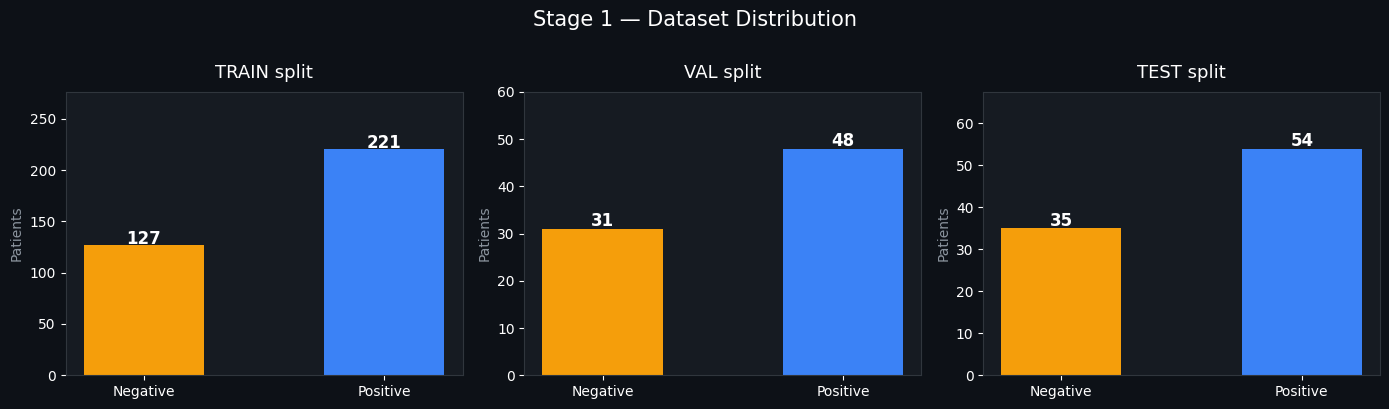

In [3]:
# Count patients per split and class
summary = {}
for split in ("train", "val", "test"):
    summary[split] = {"positive": [], "negative": []}
    for cls in ("positive", "negative"):
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        if os.path.isdir(cls_dir):
            for pid in sorted(os.listdir(cls_dir)):
                if os.path.isfile(os.path.join(cls_dir, pid, "image.npy")):
                    summary[split][cls].append(pid)

print(f"{'Split':<8} {'Positive':>10} {'Negative':>10} {'Total':>8} {'Ratio':>8}")
print("-" * 45)
for split, d in summary.items():
    p, n = len(d["positive"]), len(d["negative"])
    ratio = f"{p/n:.2f}" if n else "inf"
    print(f"{split:<8} {p:>10} {n:>10} {p+n:>8} {ratio:>8}")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor="#0d1117")
colors = {"positive": "#3b82f6", "negative": "#f59e0b"}

for ax, split in zip(axes, ("train", "val", "test")):
    ax.set_facecolor("#161b22")
    p = len(summary[split]["positive"])
    n = len(summary[split]["negative"])
    bars = ax.bar(["Negative", "Positive"], [n, p],
                  color=[colors["negative"], colors["positive"]],
                  edgecolor="none", width=0.5)
    for bar, val in zip(bars, [n, p]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha="center", color="white", fontsize=12, fontweight="bold")
    ax.set_title(f"{split.upper()} split", color="white", fontsize=13, pad=10)
    ax.set_ylabel("Patients", color="#8b949e")
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#30363d")
    ax.set_ylim(0, max(p, n) * 1.25)

fig.suptitle("Stage 1 — Dataset Distribution", color="white", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("stage1_dataset_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()


## 3. Training History Curves

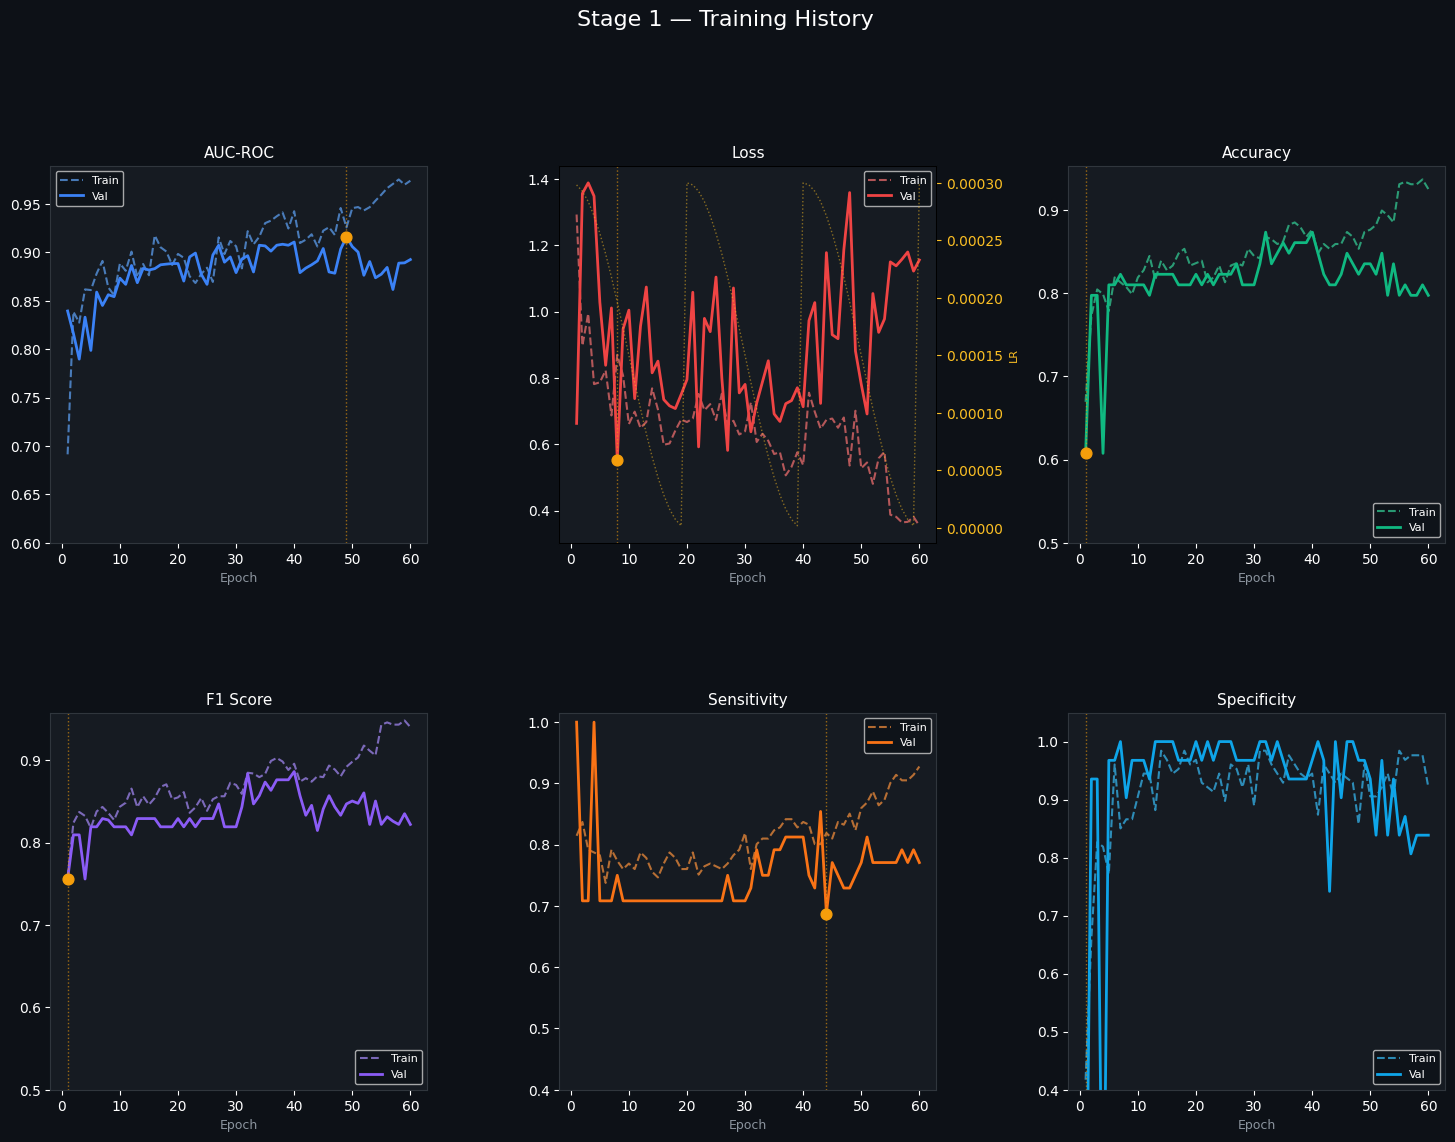


  Best val AUC : 0.9160  (epoch 49)
  Final val loss: 1.1557
  Total epochs  : 60


In [4]:
# Load training history
with open(HISTORY_JSON) as f:
    full_log = json.load(f)

# training_log.json structure: {cfg:{...}, history:[{epoch, train_loss, val_loss,...}]}
# Flatten list-of-dicts → dict-of-lists so hist["train_loss"] etc. work
history_list = full_log.get("history", full_log)  # fallback if already flat
if isinstance(history_list, list):
    hist = {}
    for key in history_list[0].keys():
        hist[key] = [ep[key] for ep in history_list if key in ep]
else:
    hist = history_list  # already a dict of lists

epochs_list = list(range(1, len(hist.get("train_loss", hist.get("epoch", []))) + 1))

fig = plt.figure(figsize=(18, 12), facecolor="#0d1117")
fig.suptitle("Stage 1 — Training History", color="white", fontsize=16, y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

def plot_metric(ax, key, label, color_t, color_v, title, ymin=None):
    ax.set_facecolor("#161b22")
    t_vals = hist.get(f"train_{key}", [])
    v_vals = hist.get(f"val_{key}",   [])
    ep     = list(range(1, len(t_vals) + 1))
    if t_vals:
        ax.plot(ep, t_vals, color=color_t, lw=1.5, alpha=0.7, label="Train", linestyle="--")
    if v_vals:
        ax.plot(ep[:len(v_vals)], v_vals, color=color_v, lw=2.0, label="Val")
        best_idx = int(np.argmax(v_vals)) if key == "auc" else int(np.argmin(v_vals))
        ax.axvline(best_idx+1, color="#f59e0b", lw=1, alpha=0.6, linestyle=":")
        ax.scatter([best_idx+1], [v_vals[best_idx]], color="#f59e0b", s=60, zorder=5)
    ax.set_title(title, color="white", fontsize=11)
    ax.set_xlabel("Epoch", color="#8b949e", fontsize=9)
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#30363d")
    ax.legend(facecolor="#0d1117", labelcolor="white", fontsize=8)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

plot_metric(ax0, "auc",  "AUC", "#60a5fa", "#3b82f6", "AUC-ROC", ymin=0.6)
plot_metric(ax1, "loss", "Loss","#f87171", "#ef4444", "Loss")
plot_metric(ax2, "acc",  "Acc", "#34d399", "#10b981", "Accuracy", ymin=0.5)
plot_metric(ax3, "f1",   "F1",  "#a78bfa", "#8b5cf6", "F1 Score", ymin=0.5)
plot_metric(ax4, "sens", "Sens","#fb923c", "#f97316", "Sensitivity", ymin=0.4)
plot_metric(ax5, "spec", "Spec","#38bdf8", "#0ea5e9", "Specificity", ymin=0.4)

# LR curve overlay on loss
if "lr" in hist:
    ax_lr = ax1.twinx()
    ax_lr.plot(epochs_list[:len(hist["lr"])], hist["lr"],
               color="#fbbf24", lw=1, alpha=0.5, linestyle=":")
    ax_lr.set_ylabel("LR", color="#fbbf24", fontsize=8)
    ax_lr.tick_params(colors="#fbbf24")

plt.savefig("stage1_training_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

# Print best epoch summary
best_ep = int(np.argmax(hist["val_auc"])) + 1
print(f"\n  Best val AUC : {max(hist['val_auc']):.4f}  (epoch {best_ep})")
if "val_loss" in hist:
    print(f"  Final val loss: {hist['val_loss'][-1]:.4f}")
print(f"  Total epochs  : {len(hist['train_loss'])}")


## 4. Full Test Set Evaluation

In [5]:
from torch.amp import autocast
from torch.utils.data import DataLoader

try:
    from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                                 classification_report, roc_curve,
                                 precision_recall_curve, average_precision_score)
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print("Install scikit-learn: pip install scikit-learn")

THRESHOLD = 0.5   # ← change if you want to sweep

test_ds = Stage1Dataset(DATA_ROOT, "test", augment=False, fixed_size=FIXED_SIZE)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

all_labels, all_probs, all_pids = [], [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["label"].numpy().ravel()
        pid    = os.path.basename(os.path.dirname(batch["path"][0]))

        with autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logit = model(images)

        prob = float(torch.sigmoid(logit).cpu().item())
        all_labels.append(int(labels[0]))
        all_probs.append(prob)
        all_pids.append(pid)

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= THRESHOLD).astype(int)

print(f"\n{'='*55}")
print(f"  TEST SET RESULTS  (threshold = {THRESHOLD})")
print(f"{'='*55}")
if SKLEARN_OK:
    acc  = (all_preds == all_labels).mean()
    auc  = roc_auc_score(all_labels, all_probs)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds, labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    sens = tp/(tp+fn) if (tp+fn) else 0
    spec = tn/(tn+fp) if (tn+fp) else 0
    ppv  = tp/(tp+fp) if (tp+fp) else 0
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  AUC-ROC     : {auc:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print(f"  Sensitivity : {sens:.4f}  (recall on positives)")
    print(f"  Specificity : {spec:.4f}  (recall on negatives)")
    print(f"  Precision   : {ppv:.4f}")
    print(f"\n  Confusion Matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=['Negative','Positive'])}")


  Stage1Dataset [test ]:  89 patients  pos=54  neg=35

  TEST SET RESULTS  (threshold = 0.5)
  Accuracy    : 0.7753
  AUC-ROC     : 0.8831
  F1 Score    : 0.8039
  Sensitivity : 0.7593  (recall on positives)
  Specificity : 0.8000  (recall on negatives)
  Precision   : 0.8542

  Confusion Matrix:  TN=28  FP=7  FN=13  TP=41

              precision    recall  f1-score   support

    Negative       0.68      0.80      0.74        35
    Positive       0.85      0.76      0.80        54

    accuracy                           0.78        89
   macro avg       0.77      0.78      0.77        89
weighted avg       0.79      0.78      0.78        89



## 5. Confusion Matrix & ROC Curve

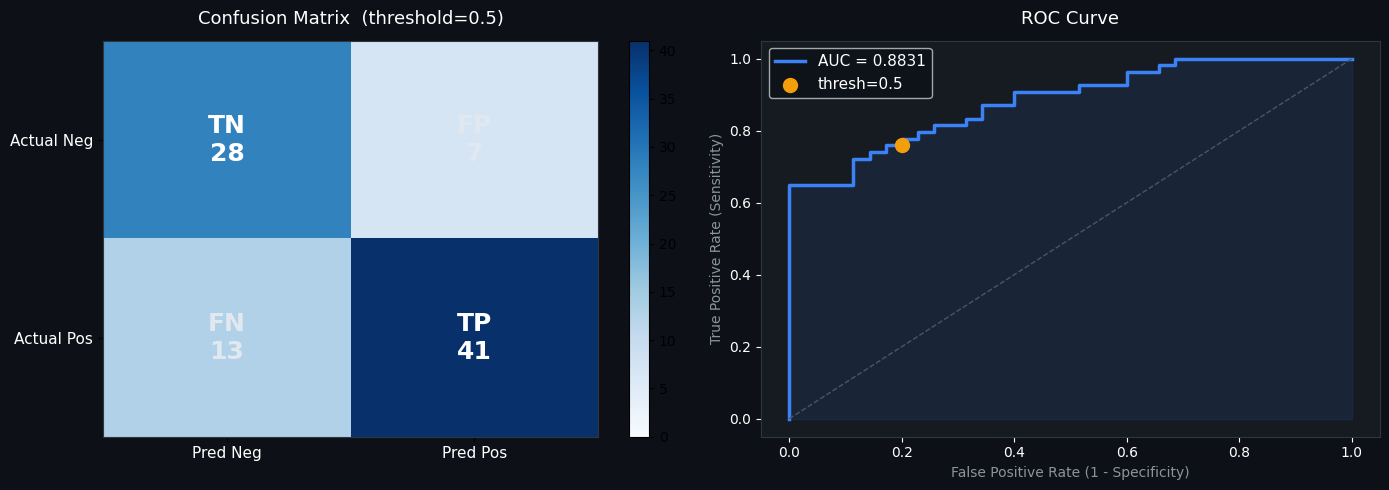

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0d1117")

# ── Confusion matrix ──────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#161b22")
cm_vals = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm_vals, cmap="Blues", aspect="auto", vmin=0)

labels_cm = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm_vals[i, j]
        color = "white" if val > cm_vals.max() * 0.5 else "#e2e8f0"
        ax.text(j, i, f"{labels_cm[i][j]}\n{val}",
                ha="center", va="center", fontsize=18, fontweight="bold", color=color)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Neg", "Pred Pos"], color="white", fontsize=11)
ax.set_yticklabels(["Actual Neg", "Actual Pos"], color="white", fontsize=11)
ax.set_title(f"Confusion Matrix  (threshold={THRESHOLD})", color="white", fontsize=13, pad=12)
ax.spines[:].set_color("#30363d")
plt.colorbar(im, ax=ax)

# ── ROC Curve ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#161b22")
if SKLEARN_OK:
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    ax2.plot(fpr, tpr, color="#3b82f6", lw=2.5, label=f"AUC = {auc:.4f}")
    ax2.plot([0,1],[0,1], color="#4b5563", lw=1, linestyle="--")
    # Mark current threshold
    idx_t = np.argmin(np.abs(thresholds - THRESHOLD))
    ax2.scatter([fpr[idx_t]], [tpr[idx_t]], color="#f59e0b", s=100, zorder=5,
                label=f"thresh={THRESHOLD}")
    # Shade AUC area
    ax2.fill_between(fpr, tpr, alpha=0.1, color="#3b82f6")
    ax2.set_xlabel("False Positive Rate (1 - Specificity)", color="#8b949e")
    ax2.set_ylabel("True Positive Rate (Sensitivity)", color="#8b949e")
    ax2.set_title("ROC Curve", color="white", fontsize=13, pad=12)
    ax2.legend(facecolor="#0d1117", labelcolor="white", fontsize=11)
    ax2.tick_params(colors="white")
    ax2.spines[:].set_color("#30363d")

plt.tight_layout()
plt.savefig("stage1_cm_roc.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()


## 6. Threshold Sweep

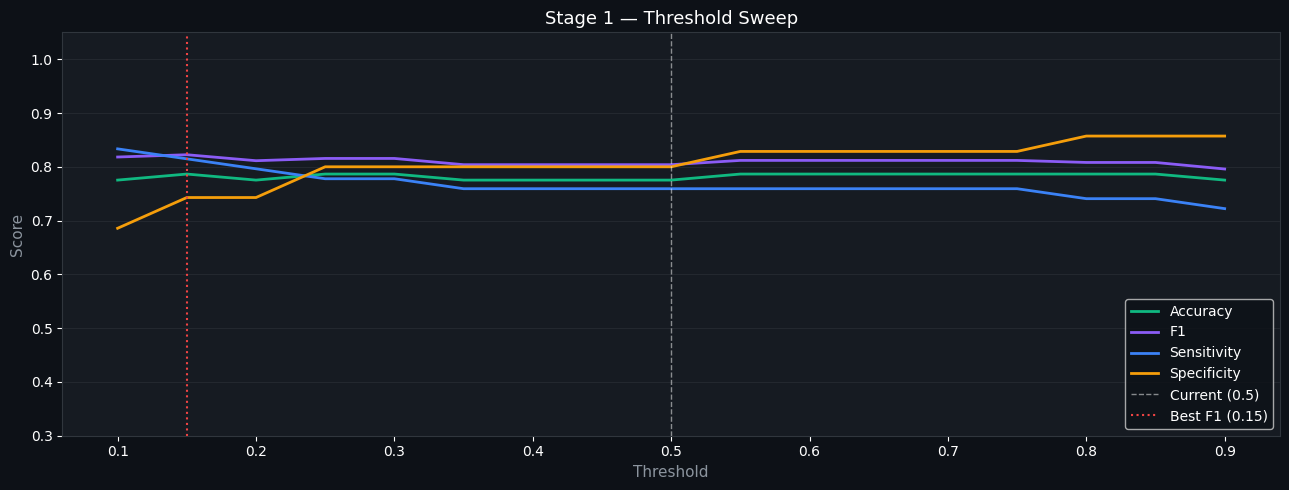


  Best F1 threshold: 0.15

   Threshold      Acc       F1     Sens     Spec
  ----------------------------------------------
        0.10   0.7753   0.8182   0.8333   0.6857
        0.15   0.7865   0.8224   0.8148   0.7429
        0.20   0.7753   0.8113   0.7963   0.7429
        0.25   0.7865   0.8155   0.7778   0.8000
        0.30   0.7865   0.8155   0.7778   0.8000
        0.35   0.7753   0.8039   0.7593   0.8000
        0.40   0.7753   0.8039   0.7593   0.8000
        0.45   0.7753   0.8039   0.7593   0.8000
        0.50   0.7753   0.8039   0.7593   0.8000 ←
        0.55   0.7865   0.8119   0.7593   0.8286
        0.60   0.7865   0.8119   0.7593   0.8286
        0.65   0.7865   0.8119   0.7593   0.8286
        0.70   0.7865   0.8119   0.7593   0.8286
        0.75   0.7865   0.8119   0.7593   0.8286
        0.80   0.7865   0.8081   0.7407   0.8571
        0.85   0.7865   0.8081   0.7407   0.8571
        0.90   0.7753   0.7959   0.7222   0.8571


In [7]:
thresholds_sweep = np.arange(0.1, 0.91, 0.05)
results_thresh = []

for t in thresholds_sweep:
    preds_t = (all_probs >= t).astype(int)
    acc_t   = (preds_t == all_labels).mean()
    f1_t    = f1_score(all_labels, preds_t, zero_division=0)
    cm_t    = confusion_matrix(all_labels, preds_t, labels=[0,1])
    tn_t,fp_t,fn_t,tp_t = cm_t.ravel()
    sens_t  = tp_t/(tp_t+fn_t) if (tp_t+fn_t) else 0
    spec_t  = tn_t/(tn_t+fp_t) if (tn_t+fp_t) else 0
    results_thresh.append((t, acc_t, f1_t, sens_t, spec_t))

fig, ax = plt.subplots(figsize=(13, 5), facecolor="#0d1117")
ax.set_facecolor("#161b22")

ts = [r[0] for r in results_thresh]
ax.plot(ts, [r[1] for r in results_thresh], color="#10b981", lw=2, label="Accuracy")
ax.plot(ts, [r[2] for r in results_thresh], color="#8b5cf6", lw=2, label="F1")
ax.plot(ts, [r[3] for r in results_thresh], color="#3b82f6", lw=2, label="Sensitivity")
ax.plot(ts, [r[4] for r in results_thresh], color="#f59e0b", lw=2, label="Specificity")
ax.axvline(THRESHOLD, color="white", lw=1, linestyle="--", alpha=0.5, label=f"Current ({THRESHOLD})")

best_f1_thresh = ts[int(np.argmax([r[2] for r in results_thresh]))]
ax.axvline(best_f1_thresh, color="#ef4444", lw=1.5, linestyle=":", label=f"Best F1 ({best_f1_thresh:.2f})")

ax.set_xlabel("Threshold", color="#8b949e", fontsize=11)
ax.set_ylabel("Score", color="#8b949e", fontsize=11)
ax.set_title("Stage 1 — Threshold Sweep", color="white", fontsize=13)
ax.legend(facecolor="#0d1117", labelcolor="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#30363d")
ax.set_ylim(0.3, 1.05)
ax.grid(axis="y", color="#30363d", alpha=0.5)

plt.tight_layout()
plt.savefig("stage1_threshold_sweep.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

print(f"\n  Best F1 threshold: {best_f1_thresh:.2f}")
print(f"\n  {'Threshold':>10} {'Acc':>8} {'F1':>8} {'Sens':>8} {'Spec':>8}")
print("  " + "-"*46)
for t, acc_t, f1_t, sens_t, spec_t in results_thresh:
    mark = " ←" if abs(t - THRESHOLD) < 0.001 else ""
    print(f"  {t:>10.2f} {acc_t:>8.4f} {f1_t:>8.4f} {sens_t:>8.4f} {spec_t:>8.4f}{mark}")


## 7. Per-Patient Probability Plot

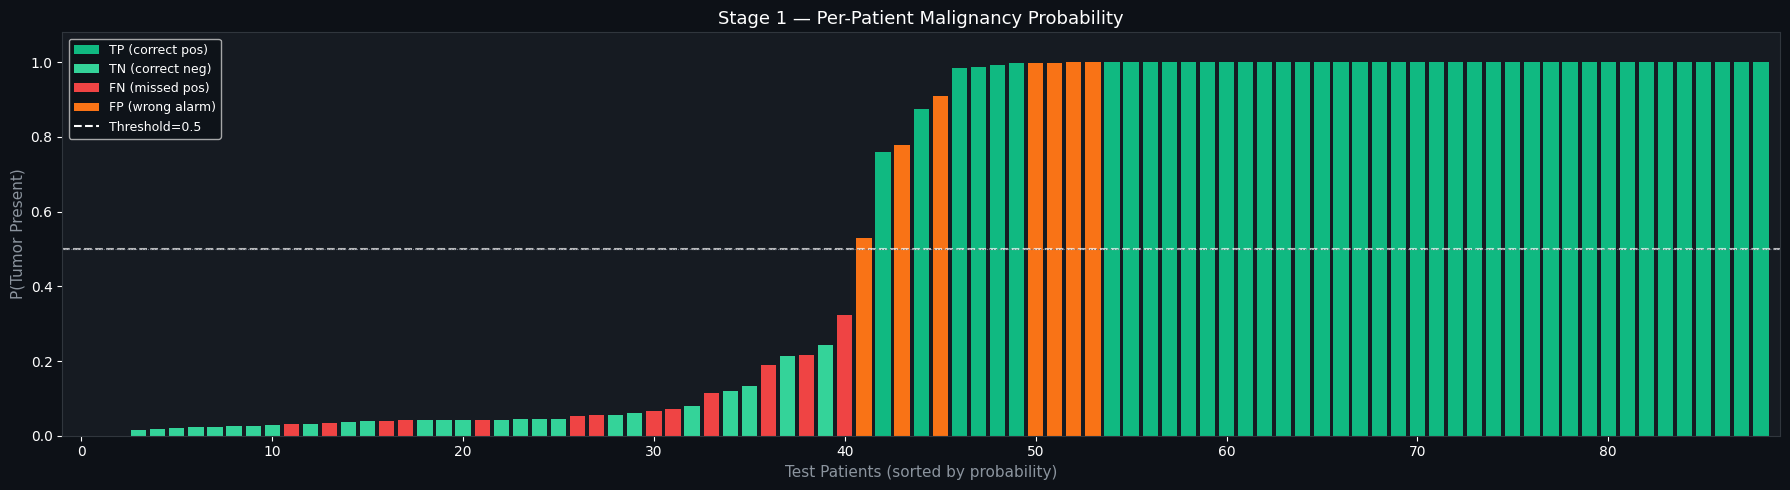

In [8]:
# Sort all patients by probability
sorted_idx = np.argsort(all_probs)
sorted_probs  = all_probs[sorted_idx]
sorted_labels = all_labels[sorted_idx]
sorted_pids   = [all_pids[i] for i in sorted_idx]

# Color: correct = green shades, wrong = red
bar_colors = []
for prob, label in zip(sorted_probs, sorted_labels):
    pred = int(prob >= THRESHOLD)
    if pred == label:
        bar_colors.append("#10b981" if label == 1 else "#34d399")
    else:
        bar_colors.append("#ef4444" if label == 1 else "#f97316")

fig, ax = plt.subplots(figsize=(18, 5), facecolor="#0d1117")
ax.set_facecolor("#161b22")
x = np.arange(len(sorted_probs))
ax.bar(x, sorted_probs, color=bar_colors, width=0.8, edgecolor="none")
ax.axhline(THRESHOLD, color="white", lw=1.5, linestyle="--", alpha=0.7,
           label=f"Threshold = {THRESHOLD}")
ax.axhline(0.5, color="#6b7280", lw=0.8, linestyle=":")

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#10b981", label="TP (correct pos)"),
    Patch(facecolor="#34d399", label="TN (correct neg)"),
    Patch(facecolor="#ef4444", label="FN (missed pos)"),
    Patch(facecolor="#f97316", label="FP (wrong alarm)"),
    plt.Line2D([0],[0], color="white", lw=1.5, linestyle="--", label=f"Threshold={THRESHOLD}"),
]
ax.legend(handles=legend_elements, facecolor="#0d1117", labelcolor="white",
          fontsize=9, loc="upper left")
ax.set_ylabel("P(Tumor Present)", color="#8b949e", fontsize=11)
ax.set_xlabel("Test Patients (sorted by probability)", color="#8b949e", fontsize=11)
ax.set_title("Stage 1 — Per-Patient Malignancy Probability", color="white", fontsize=13)
ax.tick_params(colors="white")
ax.spines[:].set_color("#30363d")
ax.set_ylim(0, 1.08)
ax.set_xlim(-1, len(sorted_probs))

plt.tight_layout()
plt.savefig("stage1_patient_probabilities.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()


## 8. MRI Volume Visualiser (Helper)

In [9]:
def load_patient_volume(patient_dir):
    """Load and resize a patient's image.npy to FIXED_SIZE."""
    from monai.transforms import Compose, SpatialPadd, CenterSpatialCropd
    img_path = os.path.join(patient_dir, "image.npy")
    if not os.path.isfile(img_path):
        raise FileNotFoundError(f"image.npy not found in {patient_dir}")
    img = np.load(img_path, allow_pickle=False).astype(np.float32)
    tf  = Compose([
        SpatialPadd(keys=["image"], spatial_size=FIXED_SIZE, mode="constant"),
        CenterSpatialCropd(keys=["image"], roi_size=FIXED_SIZE),
    ])
    img = tf({"image": img})["image"]
    if hasattr(img, "as_tensor"):
        img = img.as_tensor().numpy()
    return np.array(img)  # (3, D, H, W)


def predict_patient(patient_dir):
    """Run inference on a single patient folder."""
    img = load_patient_volume(patient_dir)
    t   = torch.from_numpy(img).unsqueeze(0).to(device)  # (1,3,D,H,W)
    model.eval()
    with torch.no_grad():
        with autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logit = model(t)
    prob = float(torch.sigmoid(logit).cpu().item())
    return prob


def show_patient_slices(patient_dir, prob=None, true_label=None,
                         n_slices=5, figsize=(18, 6)):
    """Show n_slices axial slices across 3 DCE channels."""
    img = load_patient_volume(patient_dir)   # (3, D, H, W)
    pid = os.path.basename(patient_dir)

    if prob is None:
        prob = predict_patient(patient_dir)

    pred_label = int(prob >= THRESHOLD)
    pred_str   = "POSITIVE" if pred_label == 1 else "NEGATIVE"
    color_pred = "#10b981" if pred_label == 1 else "#f59e0b"

    if true_label is not None:
        is_correct = pred_label == true_label
        status_str = "✓ CORRECT" if is_correct else "✗ WRONG"
        status_col = "#10b981" if is_correct else "#ef4444"
    else:
        status_str = ""
        status_col = "white"

    D = img.shape[1]
    slice_indices = np.linspace(D * 0.15, D * 0.85, n_slices, dtype=int)

    fig, axes = plt.subplots(3, n_slices, figsize=figsize, facecolor="#0d1117")
    channel_names = ["P1 (pre-contrast)", "P2 (early post)", "P3 (late post)"]
    cmaps = ["gray", "inferno", "viridis"]

    for ch in range(3):
        for si, sl_idx in enumerate(slice_indices):
            ax = axes[ch, si]
            ax.set_facecolor("#000")
            slc = img[ch, sl_idx]
            p1, p99 = np.percentile(slc[slc > 0], [1, 99]) if slc.max() > 0 else (0, 1)
            ax.imshow(slc, cmap=cmaps[ch], vmin=p1, vmax=p99, aspect="auto")
            ax.axis("off")
            if si == 0:
                ax.set_ylabel(channel_names[ch], color="white", fontsize=9)
            if ch == 0:
                ax.set_title(f"z={sl_idx}", color="#8b949e", fontsize=8)

    title = f"Patient: {pid}   Prob={prob:.4f}   Pred: {pred_str}"
    if status_str:
        title += f"   {status_str}"
    fig.suptitle(title, color="white", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"stage1_slices_{pid}.png", dpi=120, bbox_inches="tight",
                facecolor="#0d1117")
    plt.show()
    return prob


print("  Visualiser functions loaded.")
print("  Usage: show_patient_slices(patient_dir, prob=None, true_label=None)")


  Visualiser functions loaded.
  Usage: show_patient_slices(patient_dir, prob=None, true_label=None)


## 9. Specific Patient Investigation

Investigating specific patients...

  → Patient 160  (true=POS)


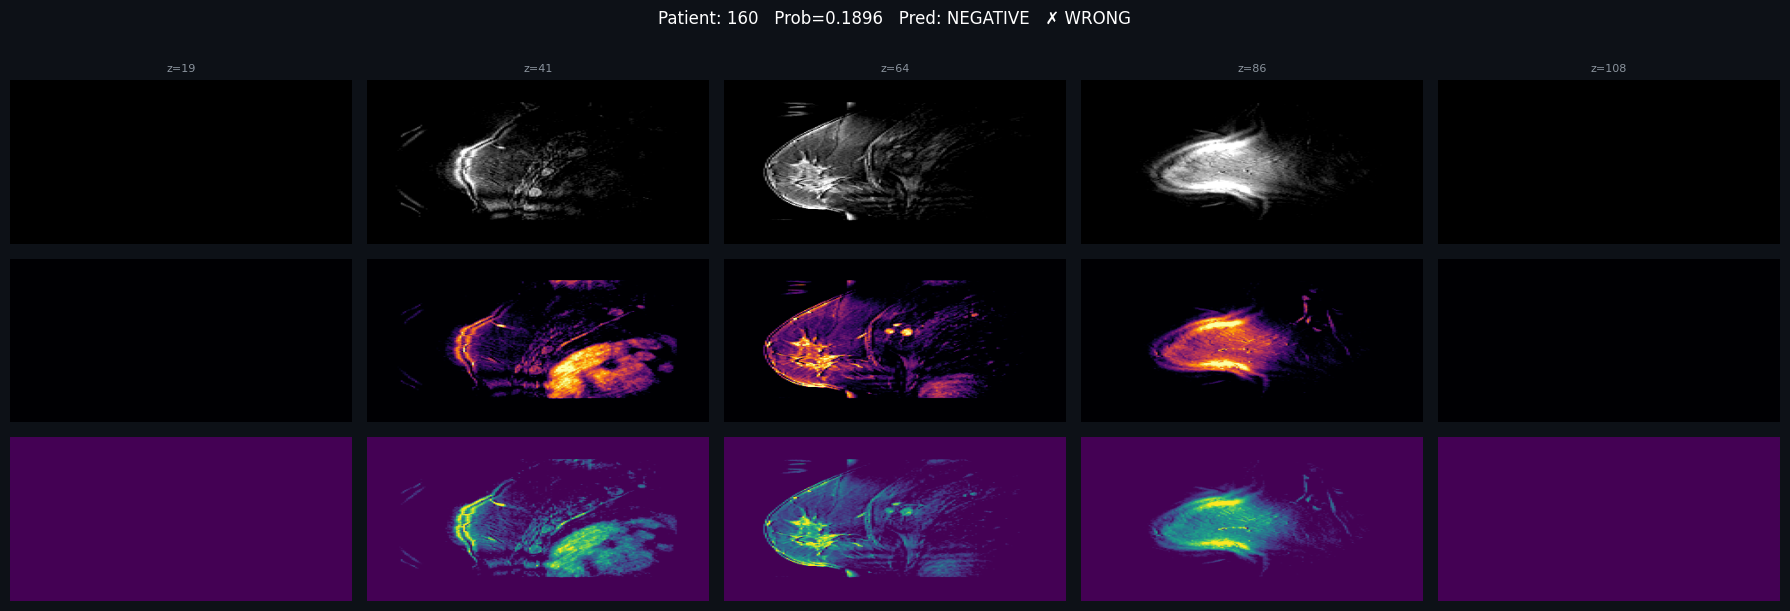


  → Patient fastMRI_breast_011  (true=POS)


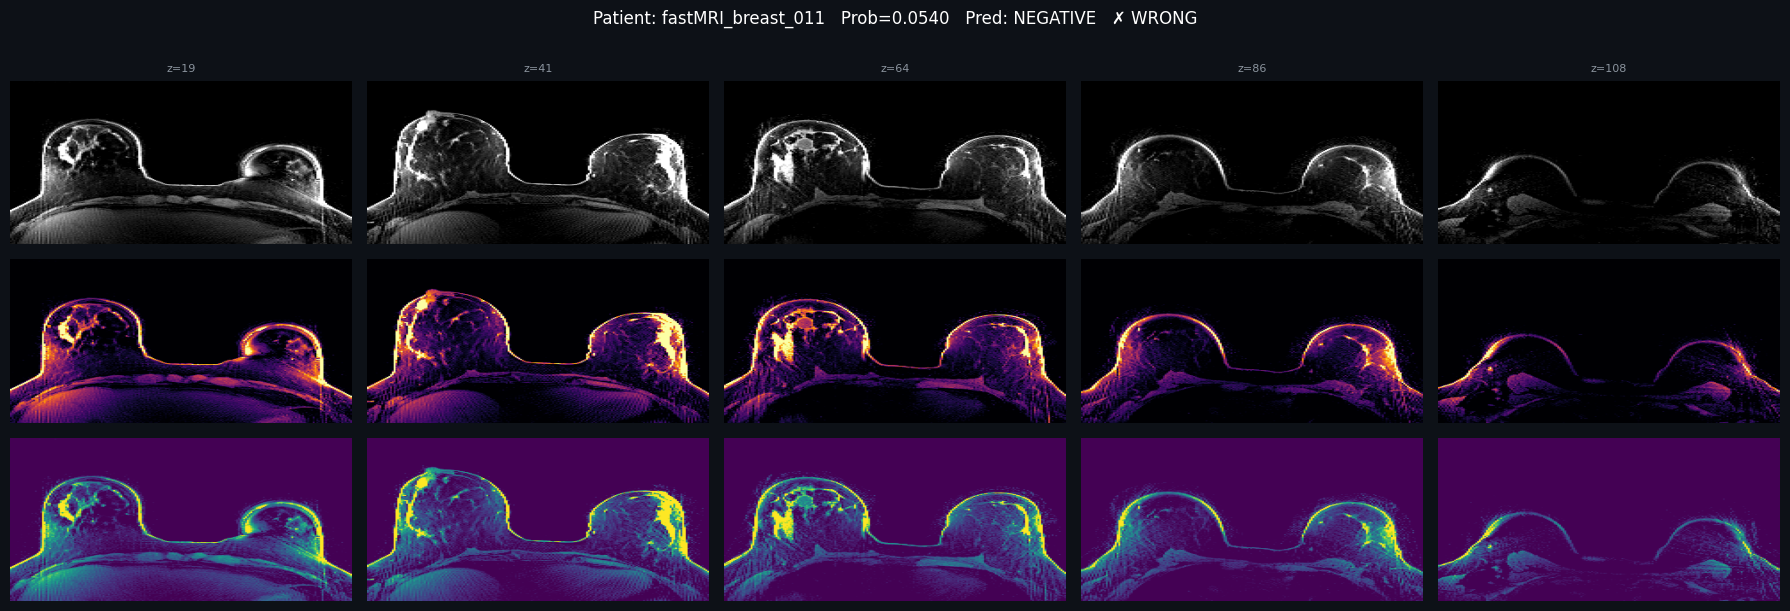


  → Patient fastMRI_breast_034  (true=NEG)


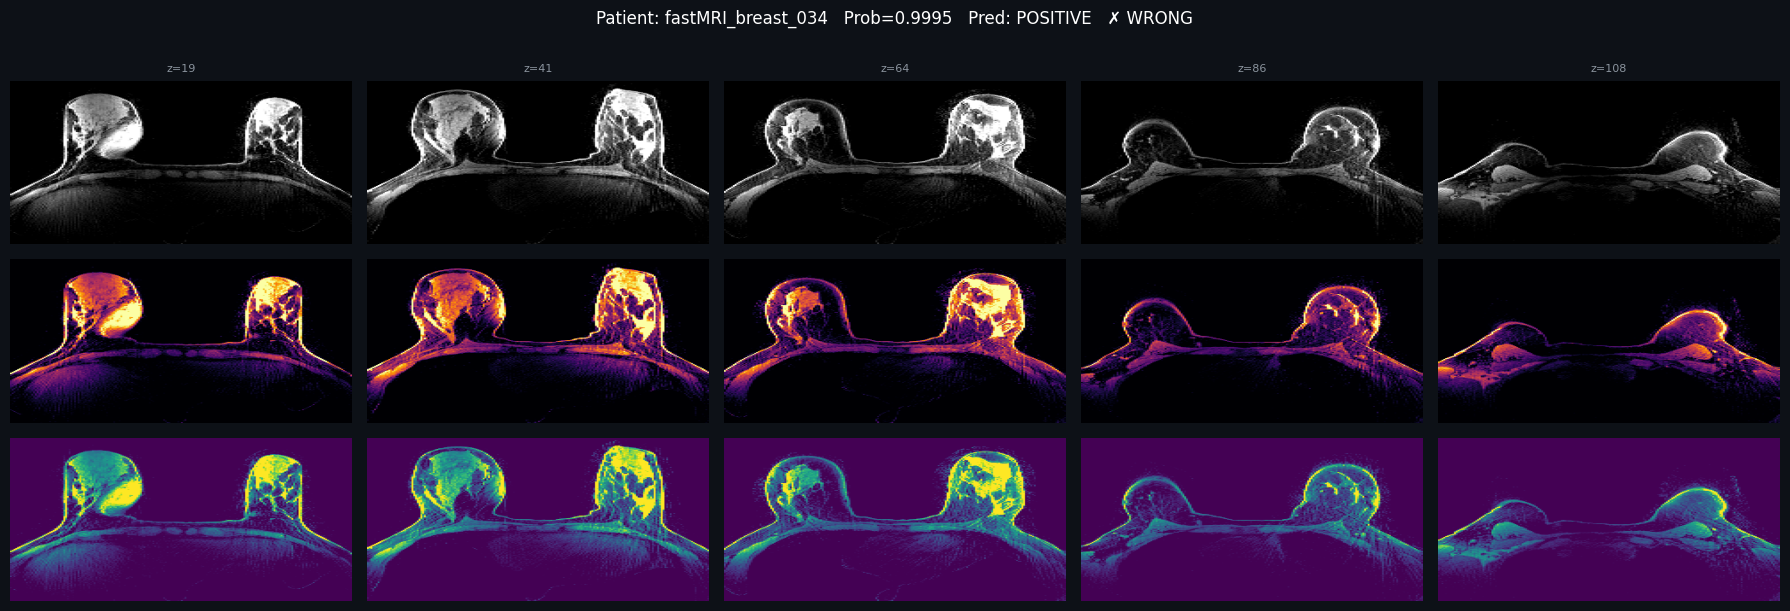


  → Patient 67  (true=POS)


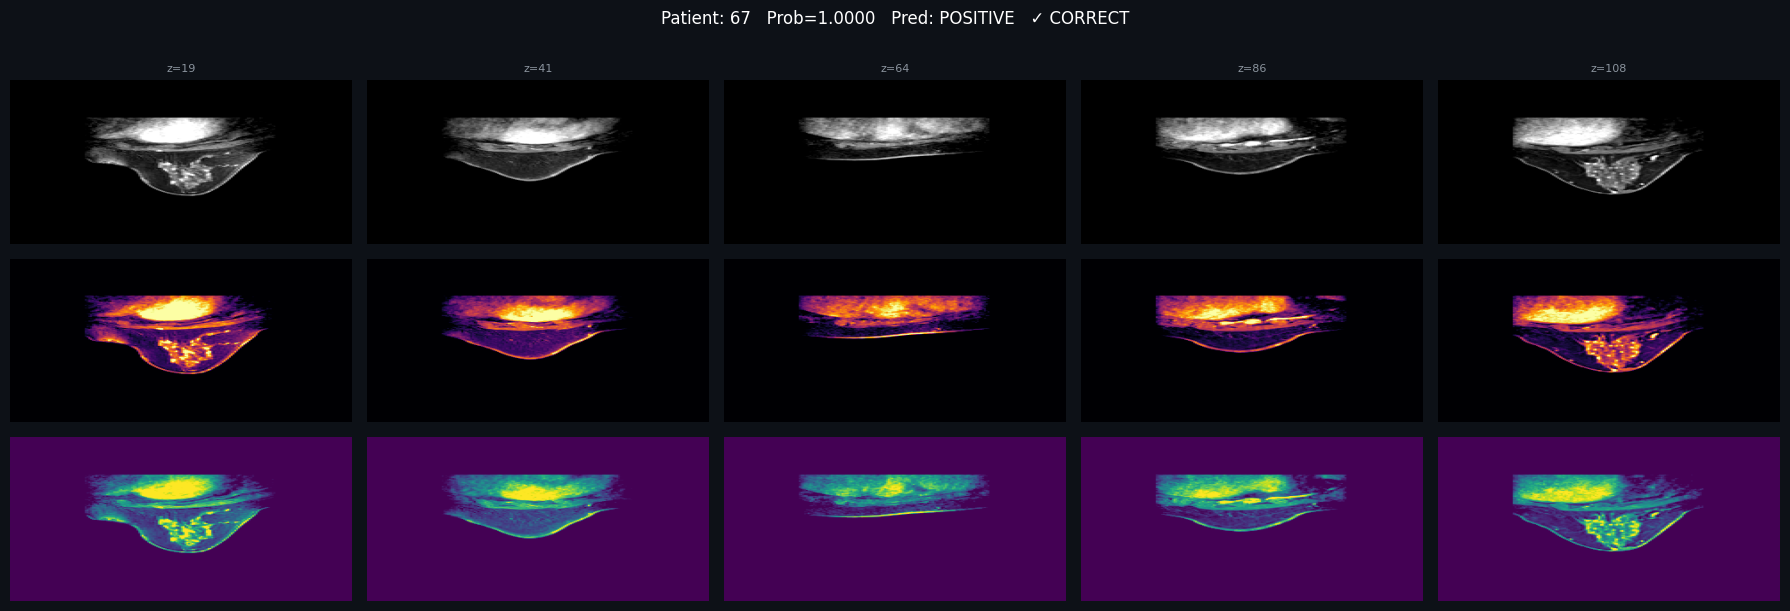


  → Patient 234  (true=NEG)


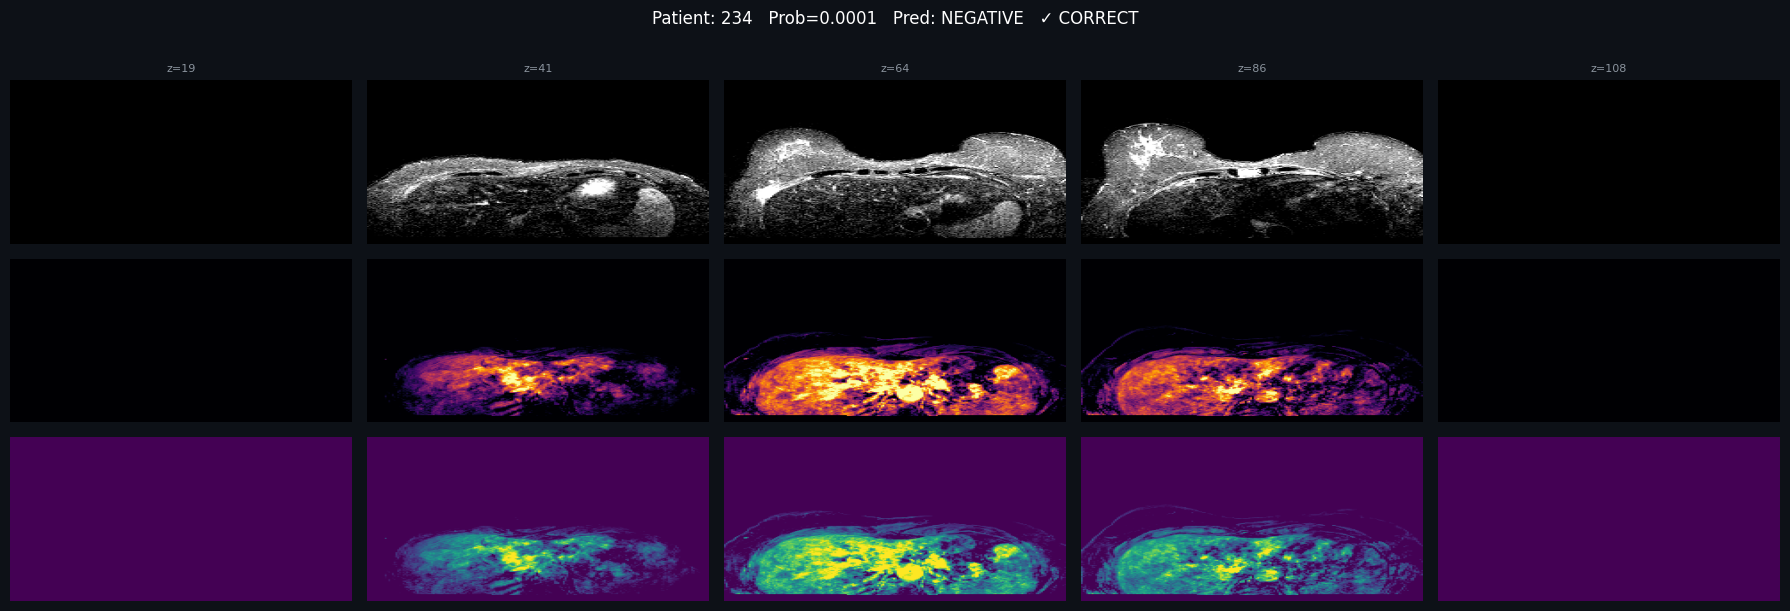

In [10]:
# ─── Edit patient IDs here ─────────────────────────────────────────
SPECIFIC_PATIENTS = [
    # (patient_id, split, class, true_label)
    # true_label: 1=positive, 0=negative
    ("160",               "test", "positive",  1),   # FN — missed tumour
    ("fastMRI_breast_011","test", "positive",  1),   # FN — fastMRI miss
    ("fastMRI_breast_034","test", "negative",  0),   # FP — false alarm
    ("67",                "test", "positive",  1),   # TP — confident correct
    ("234",               "test", "negative",  0),   # TN — breastdx normal
]
# ───────────────────────────────────────────────────────────────────

print("Investigating specific patients...\n")
for pid, split, cls, true_lbl in SPECIFIC_PATIENTS:
    patient_dir = os.path.join(DATA_ROOT, split, cls, pid)
    if not os.path.isdir(patient_dir):
        print(f"  [SKIP] {pid} — directory not found: {patient_dir}")
        continue
    print(f"  → Patient {pid}  (true={'POS' if true_lbl else 'NEG'})")
    show_patient_slices(patient_dir, true_label=true_lbl)
    print()


## 10. Random Patient Gallery

Showing 6 random test patients:



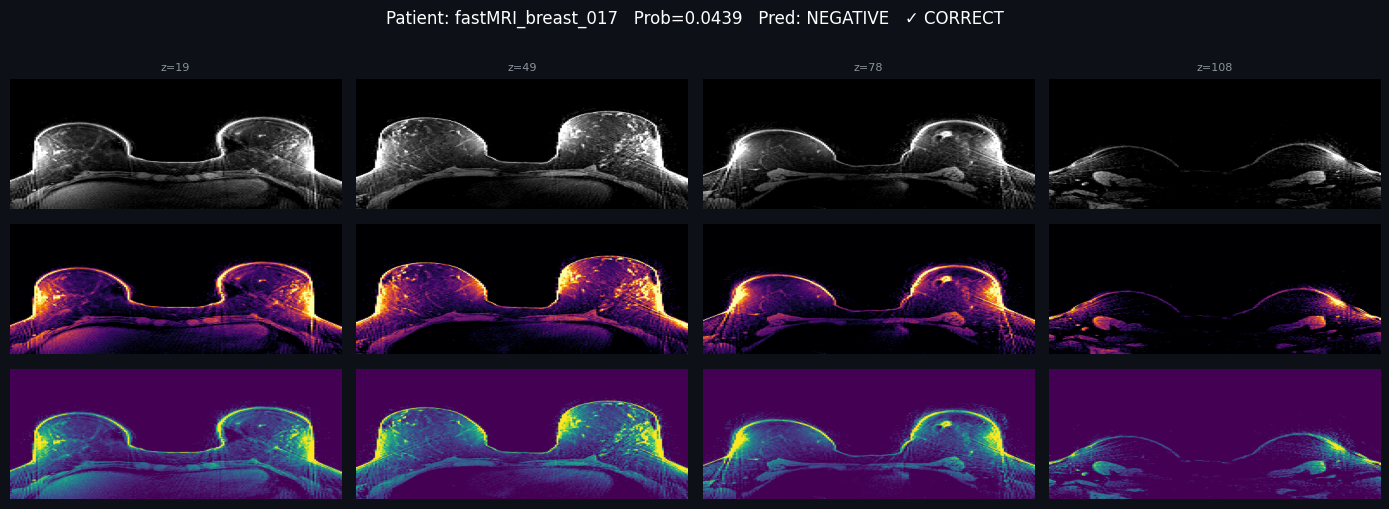

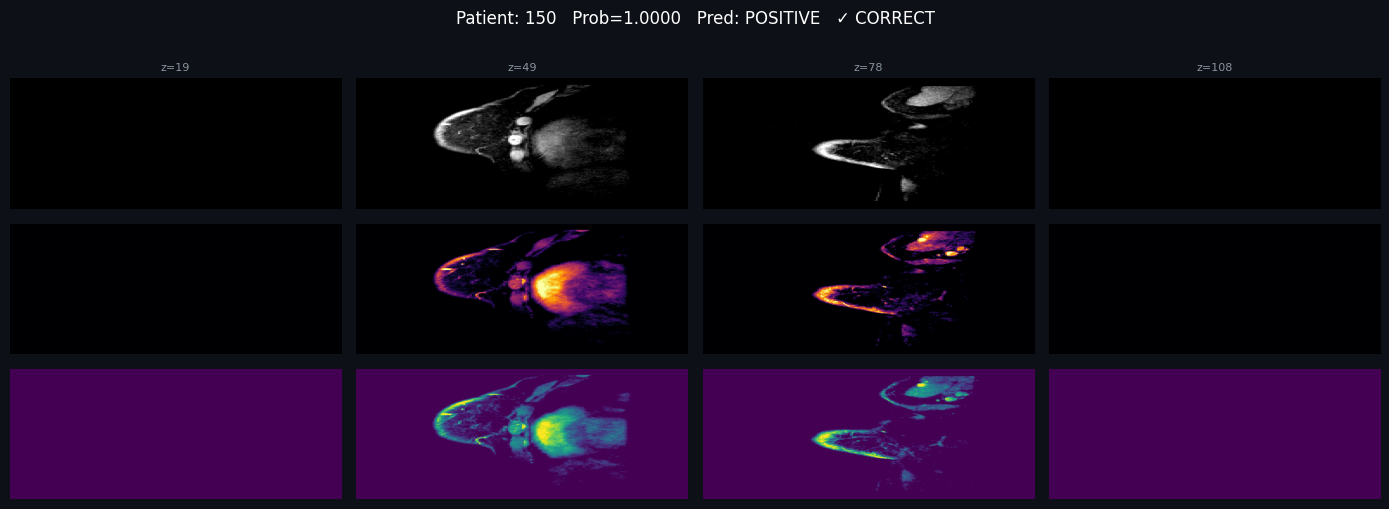

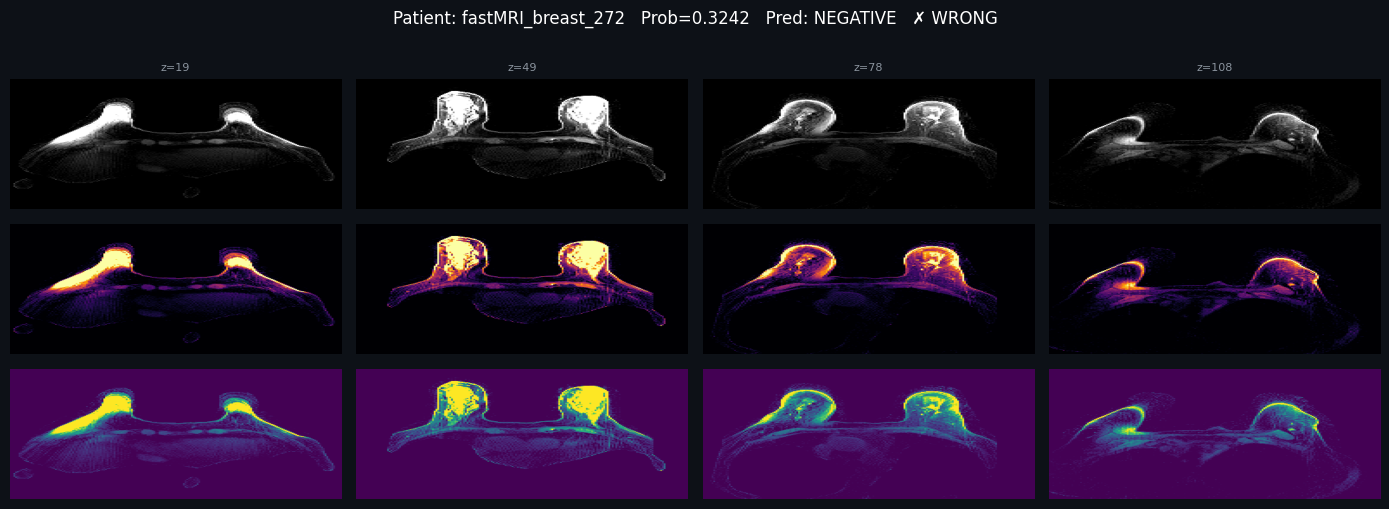

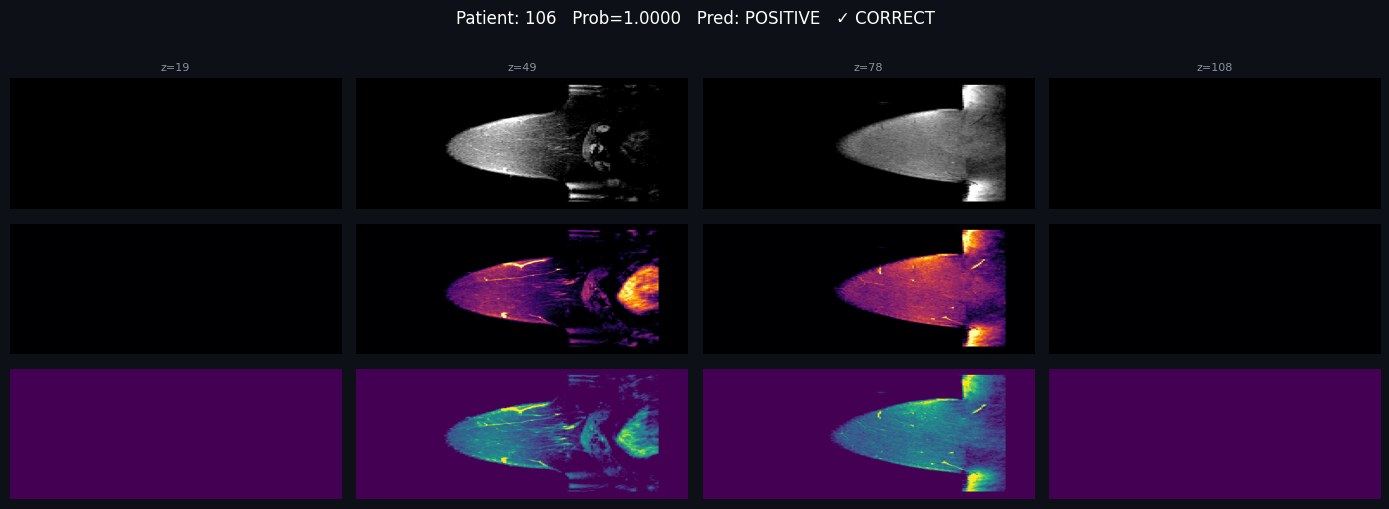

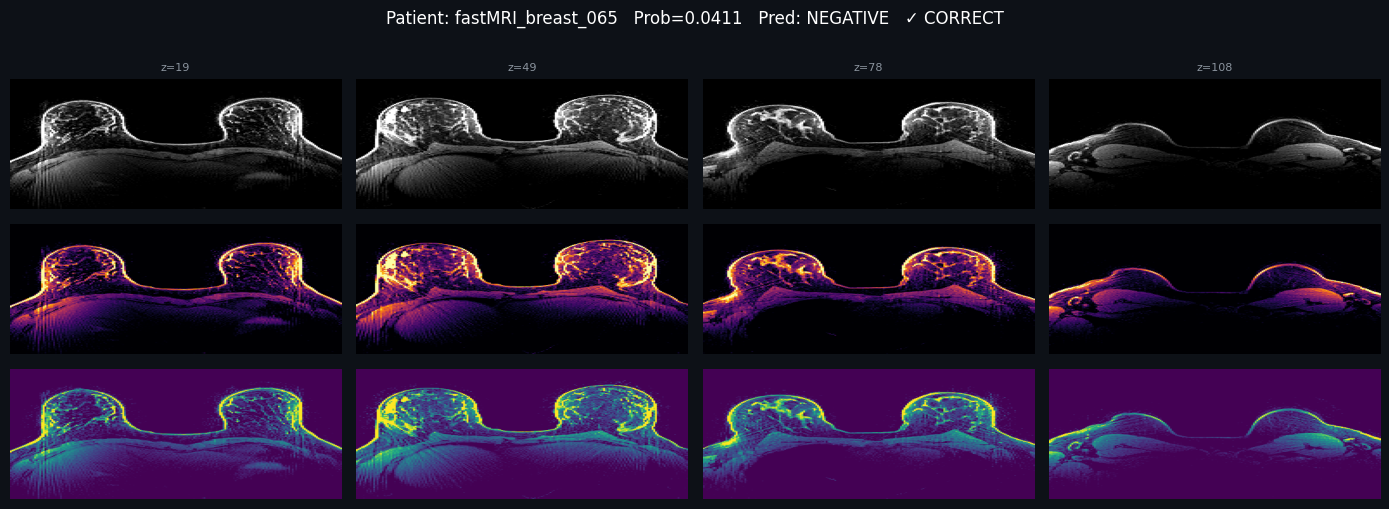

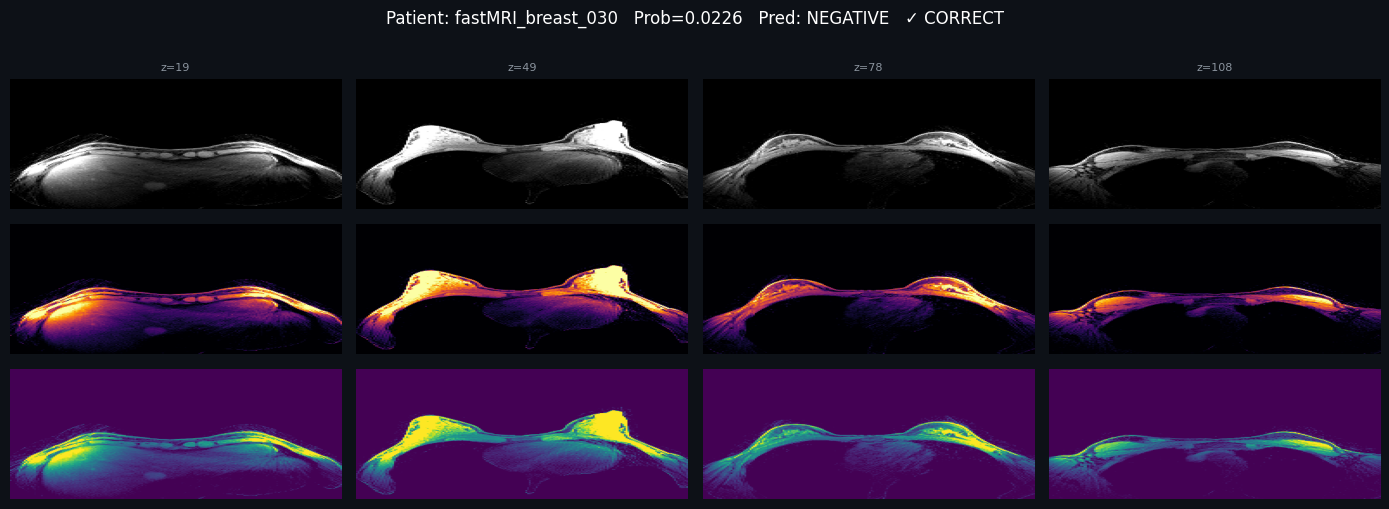

In [11]:
# Pick N random patients from the test set, mixing classes
N_RANDOM = 6   # ← change how many to show

random.seed(42)
random_picks = []

# Build pool from test set
for cls, lbl in [("positive", 1), ("negative", 0)]:
    cls_dir = os.path.join(DATA_ROOT, "test", cls)
    if os.path.isdir(cls_dir):
        pids = [p for p in os.listdir(cls_dir)
                if os.path.isfile(os.path.join(cls_dir, p, "image.npy"))]
        for pid in pids:
            random_picks.append((pid, "test", cls, lbl))

random.shuffle(random_picks)
random_picks = random_picks[:N_RANDOM]

print(f"Showing {N_RANDOM} random test patients:\n")
for pid, split, cls, true_lbl in random_picks:
    patient_dir = os.path.join(DATA_ROOT, split, cls, pid)
    show_patient_slices(patient_dir, true_label=true_lbl, n_slices=4, figsize=(14, 5))
    print()


## 11. Error Analysis — FP & FN Breakdown

Total errors: 20  (FN=13  FP=7)

False Negatives (missed tumours):
  Patient                                 Prob Source
  ------------------------------------------------------------
  fastMRI_breast_286                    0.0317  fast_mri
  fastMRI_breast_283                    0.0335  fast_mri
  fastMRI_breast_289                    0.0400  fast_mri
  fastMRI_breast_271                    0.0408  fast_mri
  fastMRI_breast_114                    0.0432  fast_mri
  fastMRI_breast_011                    0.0540  fast_mri
  fastMRI_breast_294                    0.0542  fast_mri
  fastMRI_breast_269                    0.0651  fast_mri
  fastMRI_breast_293                    0.0726  fast_mri
  fastMRI_breast_291                    0.1140  fast_mri
  160                                   0.1896  patients_combined
  fastMRI_breast_181                    0.2172  fast_mri
  fastMRI_breast_272                    0.3242  fast_mri

False Positives (false alarms):
  Patient                        

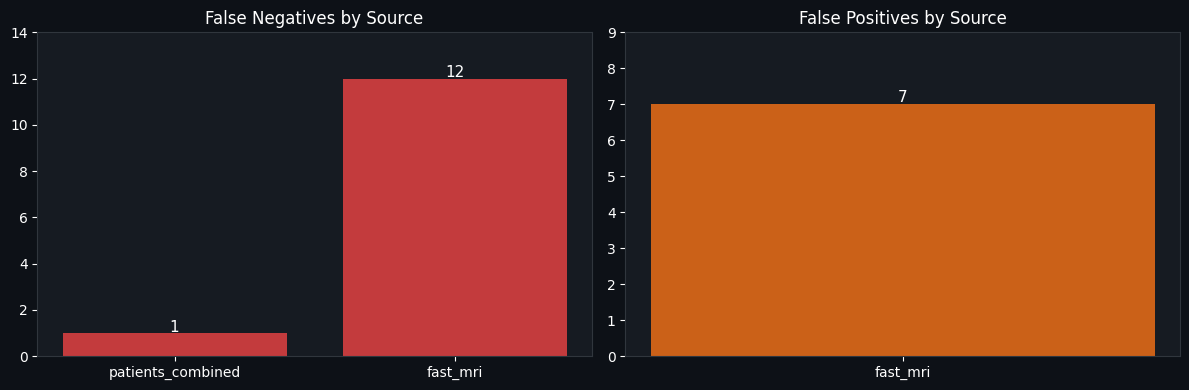

In [12]:
# Identify all errors and categorise by source
errors = []
for i, (pid, label, prob) in enumerate(zip(all_pids, all_labels, all_probs)):
    pred = int(prob >= THRESHOLD)
    if pred != label:
        source = "patients_combined" if pid[0].isdigit() else \
                 "breastdx_normal" if pid[0].isdigit() else "fast_mri"
        if "fastMRI" in pid:
            source = "fast_mri"
        elif pid[0].isdigit():
            source = "patients_combined"
        else:
            source = "breastdx_normal"
        errors.append({
            "pid": pid, "true": label, "pred": pred,
            "prob": prob, "type": "FN" if label==1 else "FP", "source": source
        })

fn_list = [e for e in errors if e["type"] == "FN"]
fp_list = [e for e in errors if e["type"] == "FP"]

print(f"Total errors: {len(errors)}  (FN={len(fn_list)}  FP={len(fp_list)})")
print()
print("False Negatives (missed tumours):")
print(f"  {'Patient':<35} {'Prob':>8} {'Source'}")
print("  " + "-"*60)
for e in sorted(fn_list, key=lambda x: x["prob"]):
    print(f"  {e['pid']:<35} {e['prob']:>8.4f}  {e['source']}")

print()
print("False Positives (false alarms):")
print(f"  {'Patient':<35} {'Prob':>8} {'Source'}")
print("  " + "-"*60)
for e in sorted(fp_list, key=lambda x: -x["prob"]):
    print(f"  {e['pid']:<35} {e['prob']:>8.4f}  {e['source']}")

# Source breakdown chart
from collections import Counter
fn_sources = Counter(e["source"] for e in fn_list)
fp_sources = Counter(e["source"] for e in fp_list)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#0d1117")
for ax, data, title, color in zip(
        axes,
        [fn_sources, fp_sources],
        ["False Negatives by Source", "False Positives by Source"],
        ["#ef4444", "#f97316"]):
    ax.set_facecolor("#161b22")
    if data:
        keys = list(data.keys())
        vals = [data[k] for k in keys]
        ax.bar(keys, vals, color=color, alpha=0.8, edgecolor="none")
        for x, v in enumerate(vals):
            ax.text(x, v + 0.05, str(v), ha="center", color="white", fontsize=11)
    ax.set_title(title, color="white", fontsize=12)
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#30363d")
    ax.set_ylim(0, max(vals)+2 if data else 5)

plt.tight_layout()
plt.savefig("stage1_error_analysis.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()


## 12. Summary Card

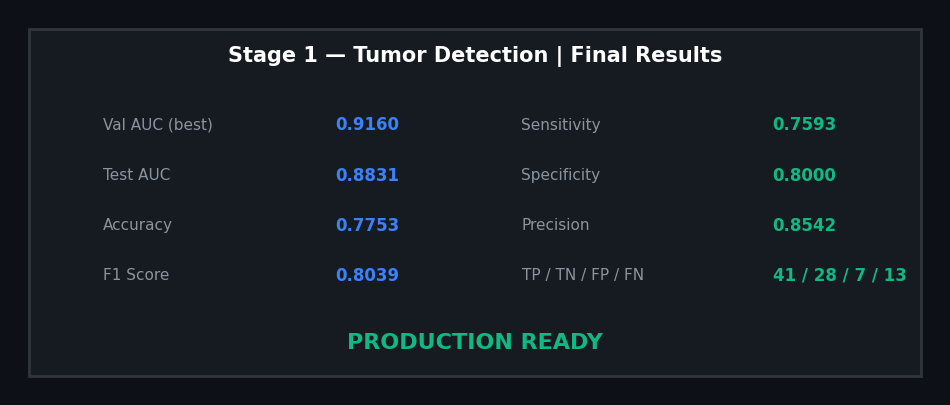


  Stage 1 pipeline notebook complete.
  Model checkpoint: D:\Breast_Tumor_AI_Project\models\classification_stage1\best_model.pth


In [13]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.axis("off")

# Main card background
card = plt.Rectangle((0.02, 0.05), 0.96, 0.9, transform=ax.transAxes,
                      facecolor="#161b22", edgecolor="#30363d", linewidth=2,
                      zorder=1, clip_on=False)
ax.add_patch(card)

ax.text(0.5, 0.88, "Stage 1 — Tumor Detection | Final Results",
        transform=ax.transAxes, ha="center", color="white",
        fontsize=15, fontweight="bold", va="center")

metrics_left = [
    ("Val AUC (best)",  f"{max(hist['val_auc']):.4f}"),
    ("Test AUC",        f"{auc:.4f}"),
    ("Accuracy",        f"{acc:.4f}"),
    ("F1 Score",        f"{f1:.4f}"),
]
metrics_right = [
    ("Sensitivity",     f"{sens:.4f}"),
    ("Specificity",     f"{spec:.4f}"),
    ("Precision",       f"{ppv:.4f}"),
    (f"TP / TN / FP / FN", f"{tp} / {tn} / {fp} / {fn}"),
]

for i, (k, v) in enumerate(metrics_left):
    y = 0.70 - i * 0.13
    ax.text(0.10, y, k, transform=ax.transAxes, color="#8b949e", fontsize=11, va="center")
    ax.text(0.35, y, v, transform=ax.transAxes, color="#3b82f6", fontsize=12,
            fontweight="bold", va="center")

for i, (k, v) in enumerate(metrics_right):
    y = 0.70 - i * 0.13
    ax.text(0.55, y, k, transform=ax.transAxes, color="#8b949e", fontsize=11, va="center")
    ax.text(0.82, y, v, transform=ax.transAxes, color="#10b981", fontsize=12,
            fontweight="bold", va="center")

status_text = "PRODUCTION READY" if auc >= 0.88 else "NEEDS IMPROVEMENT"
status_col  = "#10b981" if auc >= 0.88 else "#f59e0b"
ax.text(0.5, 0.12, status_text, transform=ax.transAxes, ha="center",
        color=status_col, fontsize=16, fontweight="bold")

plt.savefig("stage1_summary_card.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"\n  Stage 1 pipeline notebook complete.")
print(f"  Model checkpoint: {CHECKPOINT}")
